In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Phylo
import sys
sys.path.append('../pysimARG')
from clonal_genealogy import ClonalTree
from ClonalOrigin_seq_sim import ClonalOrigin_seq_sim
from localtree_simbac import load_local_trees, get_tree_at_position
from homoplasy_index_simbac import homoplasy_index_simbac
from newick_to_tree import newick_to_tree
from G4_test import G4_test
from LD_r import LD_r

In [2]:
np.random.seed(100)
clonal_tree = ClonalTree(n=10)

# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/SimBac/clonal_frame.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

edge, node_height = newick_to_tree(phylo_tree)
clonal_tree.edge = edge
clonal_tree.node_height = node_height
clonal_tree.height = np.max(node_height)
clonal_tree.length = np.sum(edge[:, 2])

rho_site = 0.02
theta_site = 0.05
L = 2000
delta = 300

                                                                   _______ 2
                                        __________________________|
                            ___________|                          |_______ 8
                           |           |
                           |           |___________________________________ 1
                           |
                        ___|                         _____________________ 6
                       |   |                       ,|
                       |   |                       ||  ___________________ 3
                       |   |                       ||_|
                       |   |_______________________|  |___________________ 9
  _____________________|                           |
 |                     |                           |         _____________ 5
 |                     |                           |________|
_|                     |                                    |_____________ 7
 |                  

## SimBac summary stats

In [3]:
genome_simbac = np.loadtxt("../data/SimBac/genomes_bool.csv", delimiter=",", dtype=bool)
genome_simbac.shape

(10, 100000)

In [4]:
file_path = "../data/SimBac/local_tree.nwk"

blocks = load_local_trees(file_path)

print(f"\nSuccessfully loaded {len(blocks)} local trees.")

print("\n--- Genome Map Overview ---")
current_position = 1

for i, (span, local_tree) in enumerate(blocks[:5]):
    end_position = current_position + span - 1
    print(f"Block {i+1}: Sites {current_position:05d} to {end_position:05d} (Length: {span}bp) - Tree has {len(local_tree.get_terminals())} leaves")
    current_position += span

Parsing local trees...

Successfully loaded 10618 local trees.

--- Genome Map Overview ---
Block 1: Sites 00001 to 00025 (Length: 25bp) - Tree has 10 leaves
Block 2: Sites 00026 to 00060 (Length: 35bp) - Tree has 10 leaves
Block 3: Sites 00061 to 00088 (Length: 28bp) - Tree has 10 leaves
Block 4: Sites 00089 to 00119 (Length: 31bp) - Tree has 10 leaves
Block 5: Sites 00120 to 00123 (Length: 4bp) - Tree has 10 leaves


In [5]:
simbac_stats = np.full((200, 6), np.nan)
simbac_stats

array([[nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan],
       ...,
       [nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan]], shape=(200, 6))

In [6]:
np.random.seed(100)
for idx in range(200):
    start_pos = np.random.randint(1, genome_simbac.shape[1]-L+1)
    mat = genome_simbac[:, start_pos-1:start_pos+L-1]

    has_true = mat.any(axis=0)
    has_false = ~mat.all(axis=0)
    idx_seg = np.where(has_true & has_false)[0]

    ld_near, ld_far, g4_near, g4_far = 0, 0, 0, 0
    if idx_seg.size >= 2:
        for i in range(idx_seg.size - 1):
            for j in range(i + 1, idx_seg.size):
                dist_ij = idx_seg[j] - idx_seg[i]
                idx_pair = [idx_seg[i], idx_seg[j]]
                if dist_ij < L/2:
                    ld_near += LD_r(mat[:, idx_pair])
                    g4_near += G4_test(mat[:, idx_pair])
                else:
                    ld_far += LD_r(mat[:, idx_pair])
                    g4_far += G4_test(mat[:, idx_pair])
        
        s_far = (int(L/2) + 1) * (int(L/2)) / 2
        s_near = L * (L - 1) / 2 - s_far
        simbac_stats[idx, 0] = ld_near / s_near
        simbac_stats[idx, 1] = ld_far / s_far
        simbac_stats[idx, 2] = g4_near / s_near
        simbac_stats[idx, 3] = g4_far / s_far
    else:
        simbac_stats[idx, :4] = 0
    
    simbac_stats[idx, 4] = homoplasy_index_simbac(blocks, genome_simbac, start_pos, L)
    count_S = idx_seg.size
    simbac_stats[idx, 5] = count_S / L

    if (idx + 1) % 100 == 0:
        print(f"Processed {idx + 1} segments...")

Processed 100 segments...
Processed 200 segments...


In [7]:
simbac_stats

array([[0.00191252, 0.00151118, 0.00195462, 0.00287512, 0.03703704,
        0.117     ],
       [0.00120079, 0.00128785, 0.00070537, 0.00094705, 0.0245098 ,
        0.0995    ],
       [0.00216764, 0.00143002, 0.00137271, 0.00268531, 0.00423729,
        0.1175    ],
       ...,
       [0.00264072, 0.00196111, 0.00138805, 0.00261938, 0.01153846,
        0.1285    ],
       [0.00266494, 0.00181972, 0.0011665 , 0.00112088, 0.02307692,
        0.127     ],
       [0.00167135, 0.00182704, 0.00168302, 0.00138262, 0.02631579,
        0.111     ]], shape=(200, 6))

## ClonalOrigin seq stats

In [8]:
clonalorigin_stats = np.full((200, 6), np.nan)
clonalorigin_stats

array([[nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan],
       ...,
       [nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan]], shape=(200, 6))

In [10]:
np.random.seed(100)
for idx in range(200):
    s_vec = ClonalOrigin_seq_sim(clonal_tree, rho_site, theta_site, L, delta)
    clonalorigin_stats[idx, :] = s_vec[:6]

    if (idx + 1) % 10 == 0:
        print(f"Processed {idx + 1} segments...")

Processed 10 segments...
Processed 20 segments...
Processed 30 segments...
Processed 40 segments...
Processed 50 segments...
Processed 60 segments...
Processed 70 segments...
Processed 80 segments...
Processed 90 segments...
Processed 100 segments...
Processed 110 segments...
Processed 120 segments...
Processed 130 segments...
Processed 140 segments...
Processed 150 segments...
Processed 160 segments...
Processed 170 segments...
Processed 180 segments...
Processed 190 segments...
Processed 200 segments...


In [11]:
clonalorigin_stats

array([[0.00475832, 0.00253287, 0.00320587, 0.00239161, 0.03954802,
        0.17      ],
       [0.00319378, 0.00241805, 0.00099766, 0.00179221, 0.02816901,
        0.138     ],
       [0.00364716, 0.0037235 , 0.0024985 , 0.00295704, 0.03975535,
        0.157     ],
       ...,
       [0.0057765 , 0.00332065, 0.00628161, 0.00834366, 0.04859335,
        0.186     ],
       [0.00209275, 0.00201289, 0.0020327 , 0.00215984, 0.03797468,
        0.114     ],
       [0.0043879 , 0.0028986 , 0.00316917, 0.00354046, 0.04142012,
        0.162     ]], shape=(200, 6))

## Visualisation

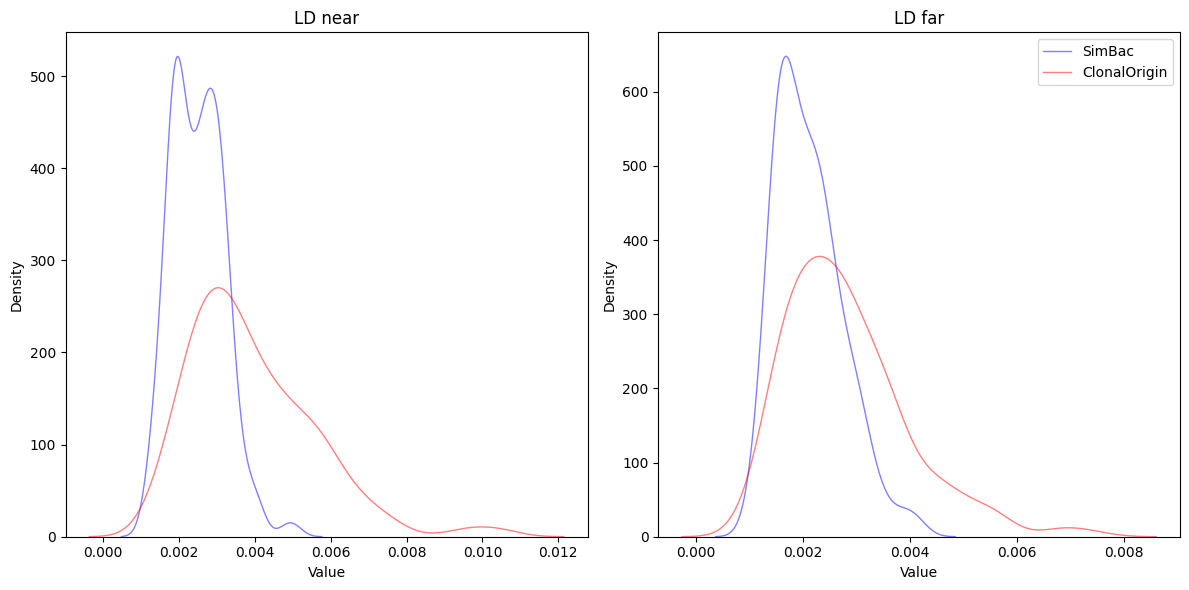

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

sns.kdeplot(data=simbac_stats[:, 0], ax=axs[0], label='SimBac', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(data=clonalorigin_stats[:, 0], ax=axs[0], label='ClonalOrigin', color='red', linewidth=1, alpha=0.5)
axs[0].set_title("LD near")
axs[0].set_xlabel("Value")

sns.kdeplot(data=simbac_stats[:, 1], ax=axs[1], label='SimBac', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(data=clonalorigin_stats[:, 1], ax=axs[1], label='ClonalOrigin', color='red', linewidth=1, alpha=0.5)
axs[1].set_title("LD far")
axs[1].set_xlabel("Value")

axs[1].legend(loc='best')

plt.tight_layout()
plt.show()

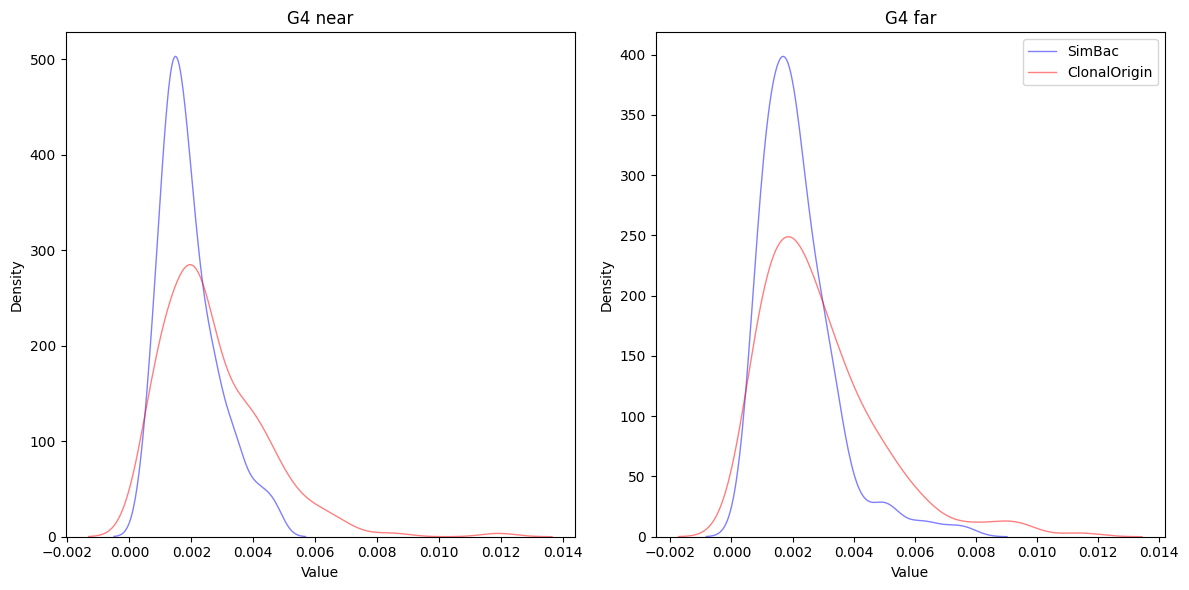

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

sns.kdeplot(data=simbac_stats[:, 2], ax=axs[0], label='SimBac', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(data=clonalorigin_stats[:, 2], ax=axs[0], label='ClonalOrigin', color='red', linewidth=1, alpha=0.5)
axs[0].set_title("G4 near")
axs[0].set_xlabel("Value")

sns.kdeplot(data=simbac_stats[:, 3], ax=axs[1], label='SimBac', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(data=clonalorigin_stats[:, 3], ax=axs[1], label='ClonalOrigin', color='red', linewidth=1, alpha=0.5)
axs[1].set_title("G4 far")
axs[1].set_xlabel("Value")

axs[1].legend(loc='best')

plt.tight_layout()
plt.show()

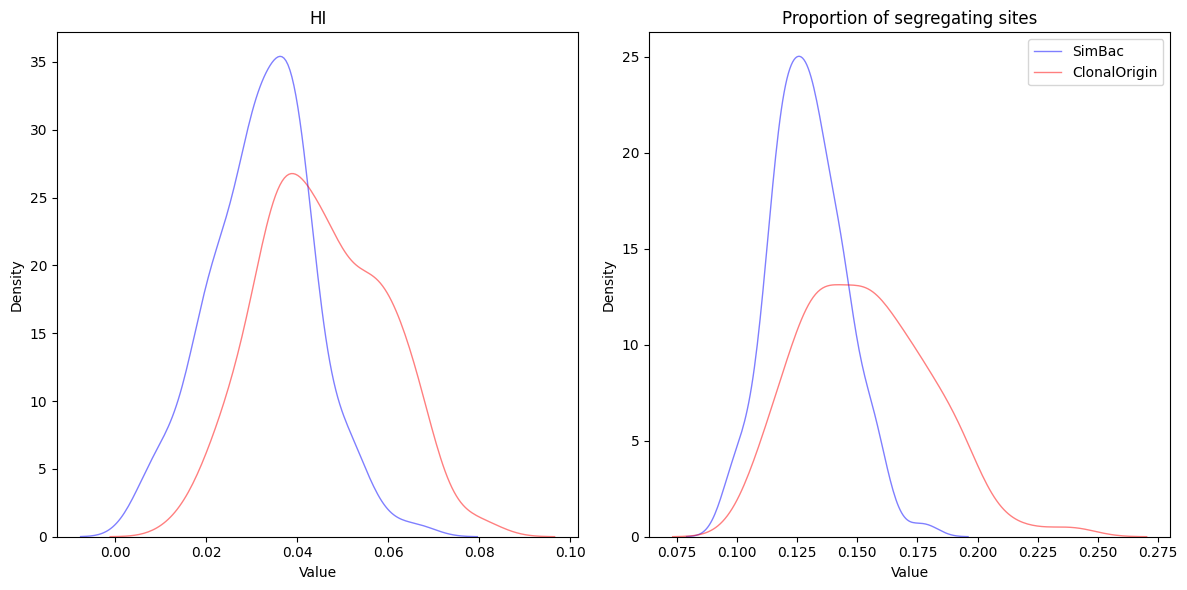

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

sns.kdeplot(data=simbac_stats[:, 4], ax=axs[0], label='SimBac', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(data=clonalorigin_stats[:, 4], ax=axs[0], label='ClonalOrigin', color='red', linewidth=1, alpha=0.5)
axs[0].set_title("HI")
axs[0].set_xlabel("Value")

sns.kdeplot(data=simbac_stats[:, 5], ax=axs[1], label='SimBac', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(data=clonalorigin_stats[:, 5], ax=axs[1], label='ClonalOrigin', color='red', linewidth=1, alpha=0.5)
axs[1].set_title("Proportion of segregating sites")
axs[1].set_xlabel("Value")

axs[1].legend(loc='best')

plt.tight_layout()
plt.show()

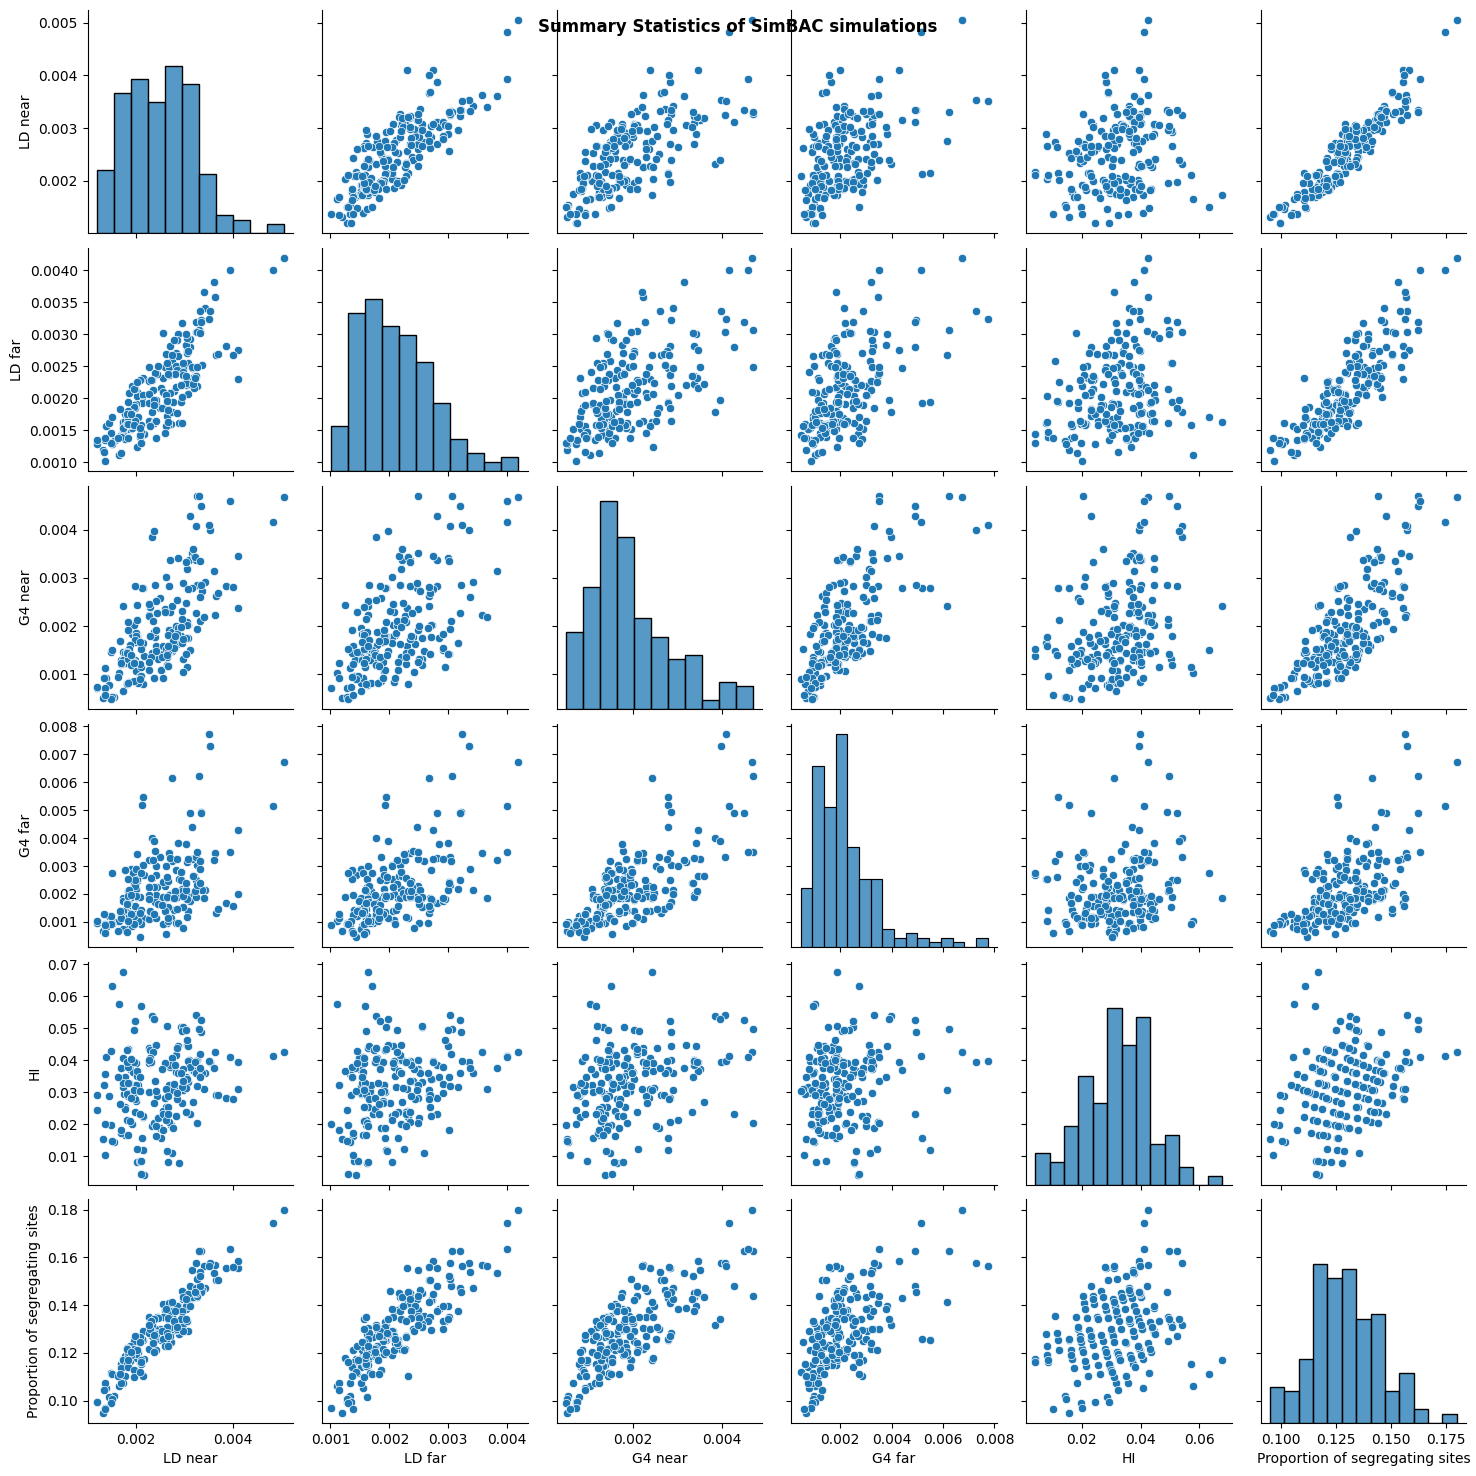

In [17]:
df_simbac_stats = pd.DataFrame(simbac_stats, columns=["LD near", "LD far",
                                                      "G4 near", "G4 far",
                                                      "HI",
                                                      "Proportion of segregating sites"])
sns.pairplot(df_simbac_stats)
plt.suptitle('Summary Statistics of SimBAC simulations', fontsize=12, fontweight='bold')
plt.show()

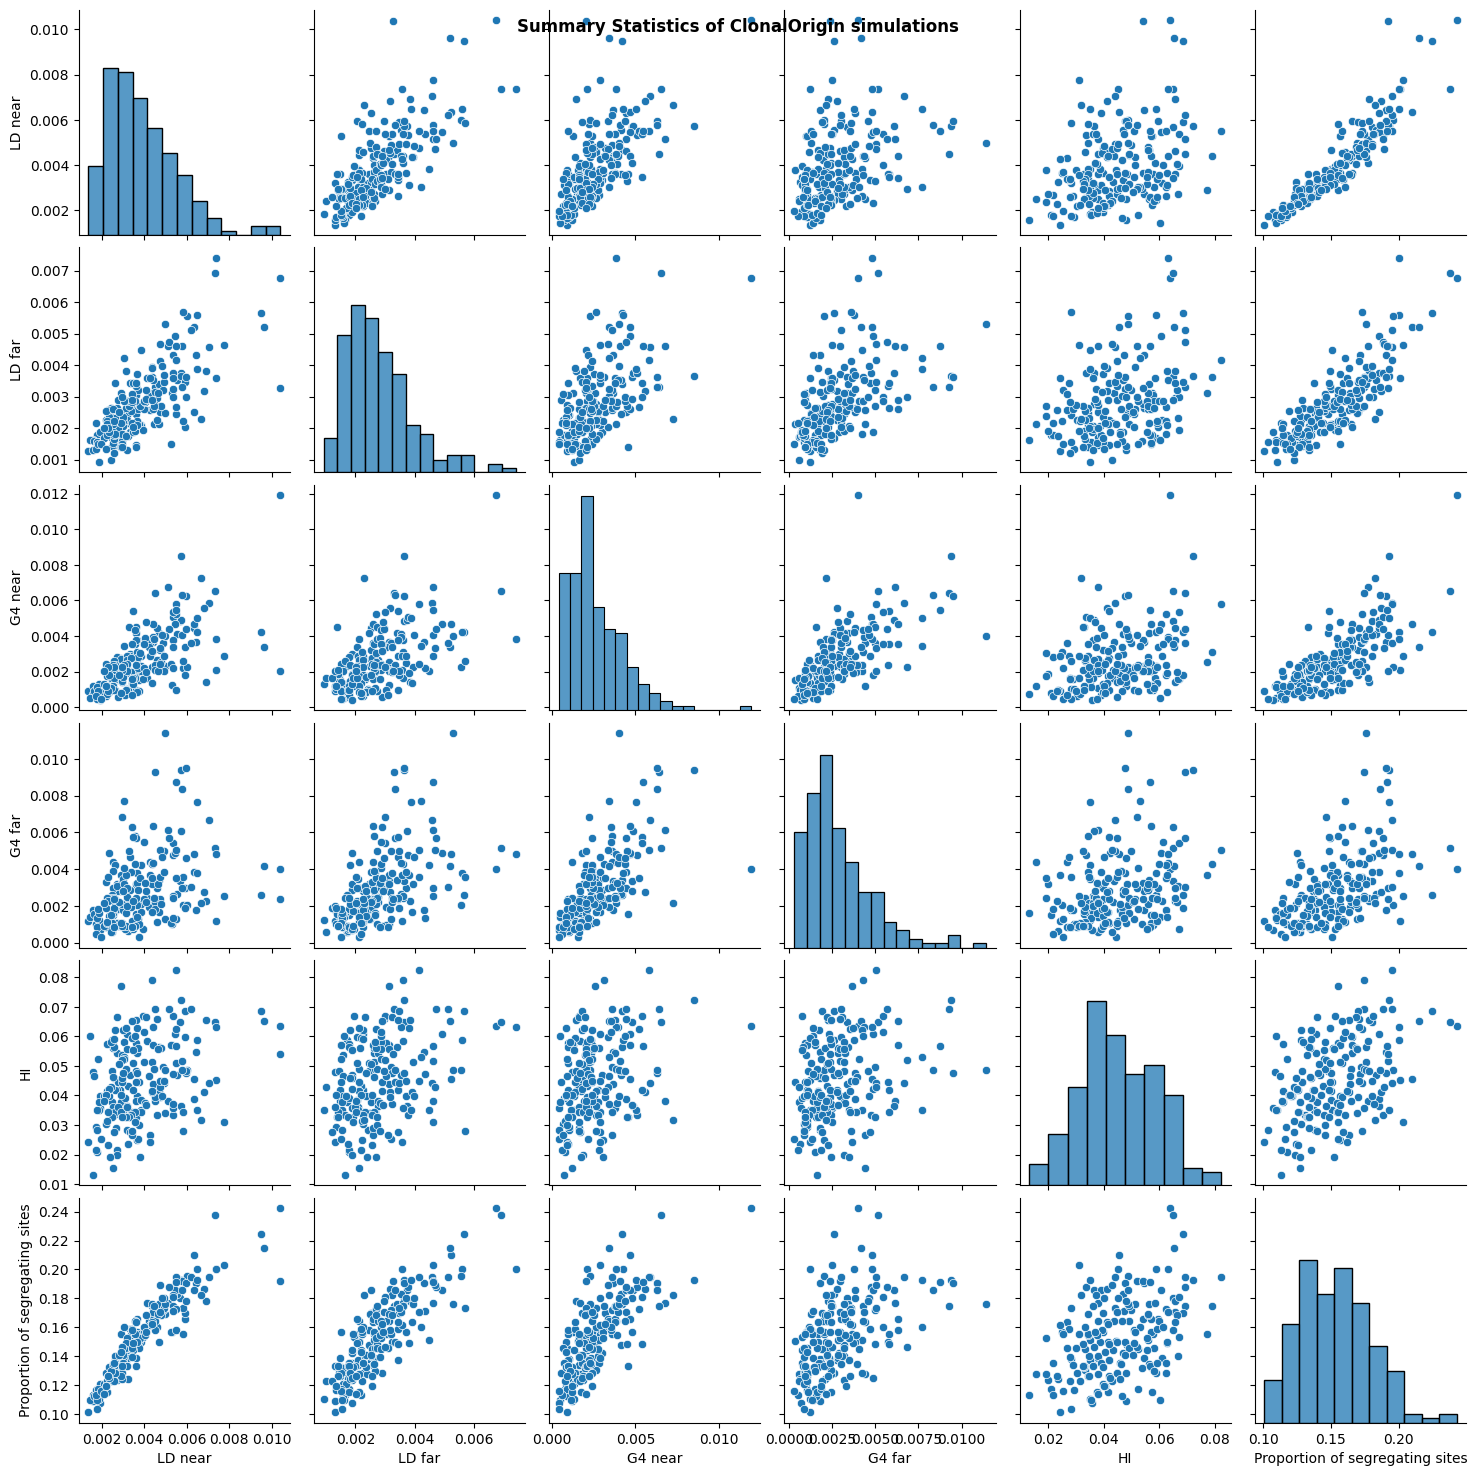

In [18]:
df_clonalorigin_stats = pd.DataFrame(clonalorigin_stats, columns=["LD near", "LD far",
                                                                  "G4 near", "G4 far",
                                                                  "HI",
                                                                  "Proportion of segregating sites"])
sns.pairplot(df_clonalorigin_stats)
plt.suptitle('Summary Statistics of ClonalOrigin simulations', fontsize=12, fontweight='bold')
plt.show()